# 房价预测

- 特征工程
- 回归模型：线性，非线性

## 导入

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer,TargetEncoder,PolynomialFeatures
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Lasso,LassoCV, Ridge,RidgeCV,ElasticNetCV, ElasticNet, LinearRegression,BayesianRidge
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.compose import TransformedTargetRegressor
import gc
import warnings
gc.enable()
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 
plt.rcParams['figure.figsize'] = (8,6) 
plt.rcParams['figure.dpi'] = 100

sns.set_theme(style="whitegrid", palette="Set1")

print(f'pd: {pd.__version__}')

pd: 2.3.1


In [2]:
traindata = pd.read_csv('data/train.csv',index_col='Id')
testdata = pd.read_csv('data/test.csv',index_col='Id')

In [62]:
traindata.shape

(1460, 80)

In [43]:
traindata.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
traindata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt    

In [4]:
traindata.describe(include='all')

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
count,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460,1460,1460,...,1460.000000,7,281,54,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000
unique,NaN,5,NaN,NaN,2,2,4,4,2,5,...,NaN,3,4,4,NaN,NaN,NaN,9,6,NaN
top,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,Inside,...,NaN,Gd,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,1151,NaN,NaN,1454,50,925,1311,1459,1052,...,NaN,3,157,49,NaN,NaN,NaN,1267,1198,NaN
mean,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN,NaN,NaN,...,2.758904,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890
std,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN,NaN,NaN,...,40.177307,NaN,NaN,NaN,496.123024,2.703626,1.328095,NaN,NaN,79442.502883
min,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,1.000000,2006.000000,NaN,NaN,34900.000000
25%,20.000000,NaN,59.000000,7553.500000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,5.000000,2007.000000,NaN,NaN,129975.000000
50%,50.000000,NaN,69.000000,9478.500000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,6.000000,2008.000000,NaN,NaN,163000.000000
75%,70.000000,NaN,80.000000,11601.500000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,8.000000,2009.000000,NaN,NaN,214000.000000


In [5]:
traindata.dtypes

MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
Street            object
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 80, dtype: object

## 字段说明
来自AI

🏠 房屋基本属性与位置

这些字段决定了房子的“骨架”和地段：

* **MSSubClass**: 房屋类型（如：1层现代风格、2层复古风格等）。
* **MSZoning**: 土地分区（如：住宅区、商业区、农业区）。
* **LotFrontage**: 房屋连接街道的距离（英尺）。
* **LotArea**: 地块面积（平方英尺）。
* **Street / Alley**: 道路/巷道的铺设类型（如：碎石、柏油）。
* **LotShape**: 地块形状（是否规整）。
* **LandContour**: 地形平坦度（如：平坦、有坡度、凹陷）。
* **Neighborhood**: 艾姆斯市内的具体社区位置。
* **BldgType**: 住宅类型（独栋、联排等）。
* **HouseStyle**: 住宅风格（一层、二层、半层等）。

🌟 整体品质与年代

* **OverallQual**: 整体材料和装饰评分（1-10分）。
* **OverallCond**: 整体状态评分（1-10分）。
* **YearBuilt**: 建造年份。
* **YearRemodAdd**: 改建年份。

🧱 外部与结构细节

* **RoofStyle / RoofMatl**: 屋顶类型和材料。
* **Exterior1st / Exterior2nd**: 房屋外墙覆盖物。
* **MasVnrType / MasVnrArea**: 砖石饰面类型及面积。
* **ExterQual / ExterCond**: 外部材料的质量和现状评分。
* **Foundation**: 地基类型（如：混凝土、砖、石头）。

🕳️ 地下室情况

* **BsmtQual / BsmtCond**: 地下室的高度评价和质量评分。
* **BsmtExposure**: 花园式地下室的采光/出口情况。
* **BsmtFinType1 / BsmtFinSF1**: 第一类型地下室完工面积及类型。
* **BsmtFinType2 / BsmtFinSF2**: 第二类型地下室完工面积。
* **BsmtUnfSF**: 未完工地下室面积。
* **TotalBsmtSF**: 地下室总面积。

🌡️ 公用设施与系统

* **Heating / HeatingQC**: 供暖类型和质量评分。
* **CentralAir**: 是否有中央空调（Y/N）。
* **Electrical**: 电气系统类型。

📐 居住面积与房间

* **1stFlrSF / 2ndFlrSF**: 一层/二层面积。
* **LowQualFinSF**: 低质量完工面积（所有楼层）。
* **GrLivArea**: 地面以上居住面积总和。
* **BsmtFullBath / BsmtHalfBath**: 地下室全卫/半卫数量。
* **FullBath / HalfBath**: 地面上全卫/半卫数量。
* **BedroomAbvGr**: 地面上卧室数量。
* **KitchenAbvGr / KitchenQual**: 厨房数量及质量评分。
* **TotRmsAbvGrd**: 地面上房间总数（不含卫浴）。
* **Fireplaces / FireplaceQu**: 壁炉数量及质量。

🚗 车库与附属设施

* **GarageType / GarageYrBlt**: 车库位置、建造年份。
* **GarageFinish / GarageCars / GarageArea**: 车库装修情况、车位数、面积。
* **GarageQual / GarageCond**: 车库质量和现状。
* **PavedDrive**: 车道铺设情况。
* **WoodDeckSF / OpenPorchSF / EnclosedPorch / 3SsnPorch / ScreenPorch**: 露台、走廊等各类户外空间的面积。
* **PoolArea / PoolQC**: 泳池面积及质量。
* **Fence**: 围栏质量。
* **MiscFeature / MiscVal**: 其他杂项特征（如：网球场、棚屋）及其价值。

💰 销售信息

* **MoSold / YrSold**: 售出月份和年份。
* **SaleType**: 销售类型（如：现金、贷款、法拍）。
* **SaleCondition**: 销售条件（如：正常交易、家庭内部转让）。
* **SalePrice**: **目标变量**，房屋售价（美元）。

## EDA
描述了数据特征探索的全部过程。 后面的处理转换都来自这里的分析

In [71]:
traindata.shape

(1460, 80)

In [74]:
traindata.dtypes.value_counts()

object     43
int64      34
float64     3
Name: count, dtype: int64

### 目标SalePrice

Text(0.5, 1.0, 'SalePrice distribution')

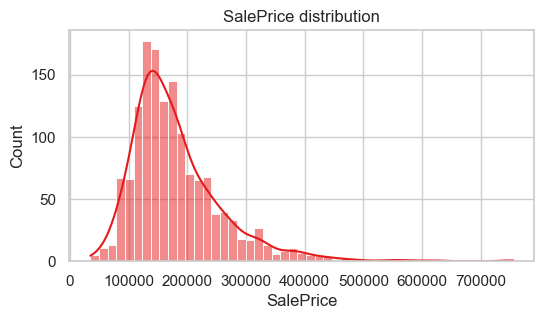

In [7]:
ax = sns.histplot(data=traindata, x='SalePrice',kde=True)
ax.set_title('SalePrice distribution')

明显是左偏分布、尖峰长尾

In [8]:
skew = traindata['SalePrice'].skew()
kurt = traindata['SalePrice'].kurt()
print(f'SalePrice: skew {skew}, kurt {kurt}')

SalePrice: skew 1.8828757597682129, kurt 6.536281860064529


### 数值特征与SalePrice相关性

In [9]:
traindata.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [10]:
traindata.select_dtypes(include=['number']).columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [11]:
traindata

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500


<Axes: >

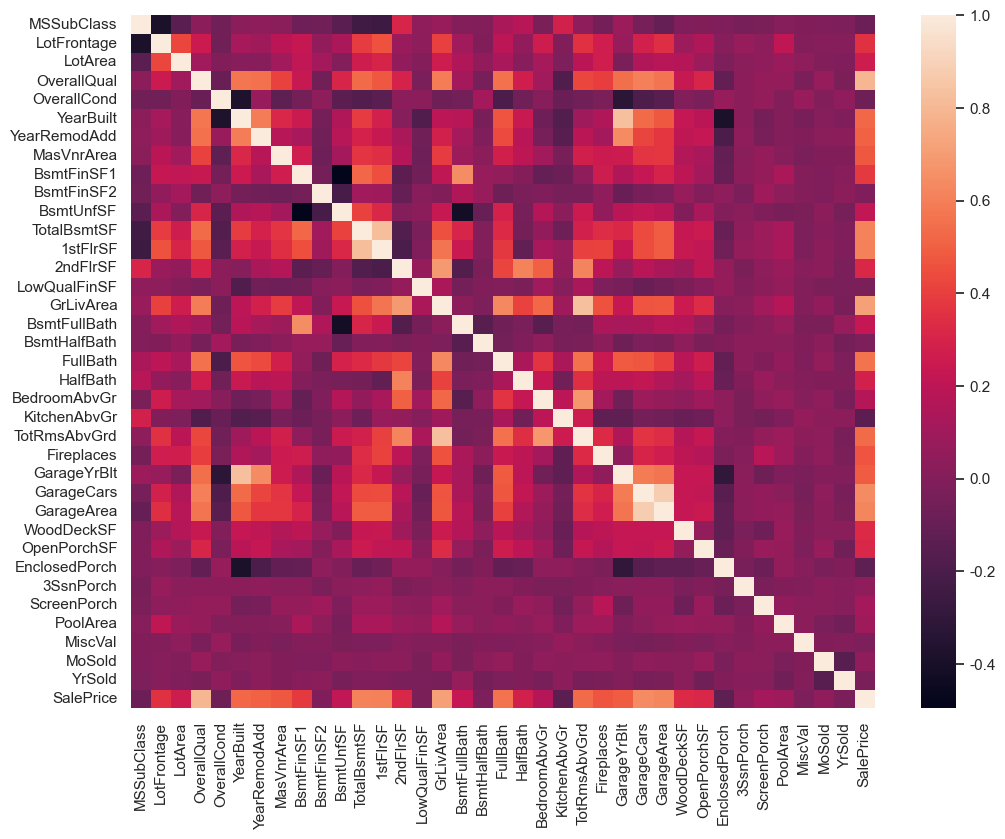

In [12]:
plt.figure(figsize=(12, 9))
corrs = traindata.corr(numeric_only=True)
sns.heatmap(data=corrs)

明显地，黑色方块
- 有几个高度共线特征
- `SalePrice`的几个相关特征：`GrLivArea`,`OverallQual`..


着重看下与`SalePrice`几个高相关特征

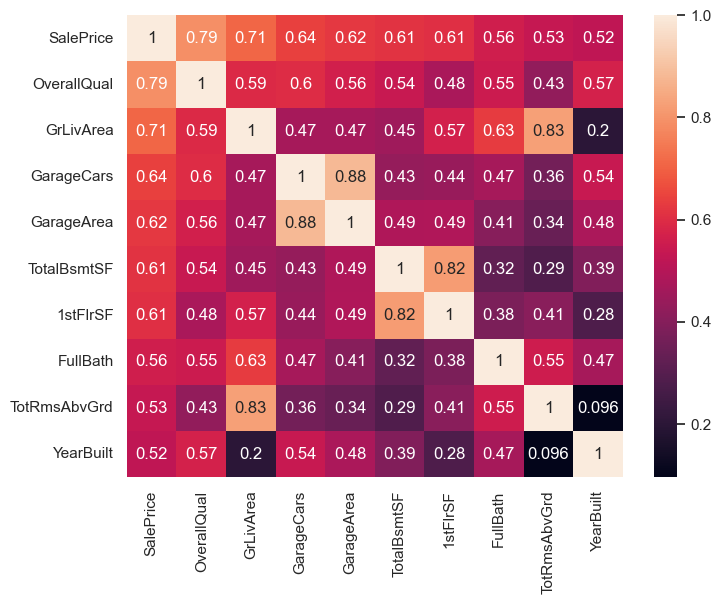

In [13]:
high10_cols = corrs.nlargest(10, 'SalePrice').index.tolist() 
high10_corrs = traindata[high10_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(data=high10_corrs, annot=True)
plt.show()

理解下这几个特征：
- *OverallQual* 房屋装潢很重要！
- *GrLivArea* 地上楼层活动面积，*TotRmsAbvGrd* 地上楼层房间数。 这两个是共线强相关的~
- *GarageCars* 车位数，*GarageArea* 车库面积 。 这两个是共线强相关的~
- *TotalBsmtSF* 地下室面积，*1stFlrSF* 一层面积。 这两个是共线强相关的~
- *FullBath* 地上楼层带有洗澡全设施的数量！！
- *YearBuilt* 建筑时间

也就是说最关键的特征大约是6各

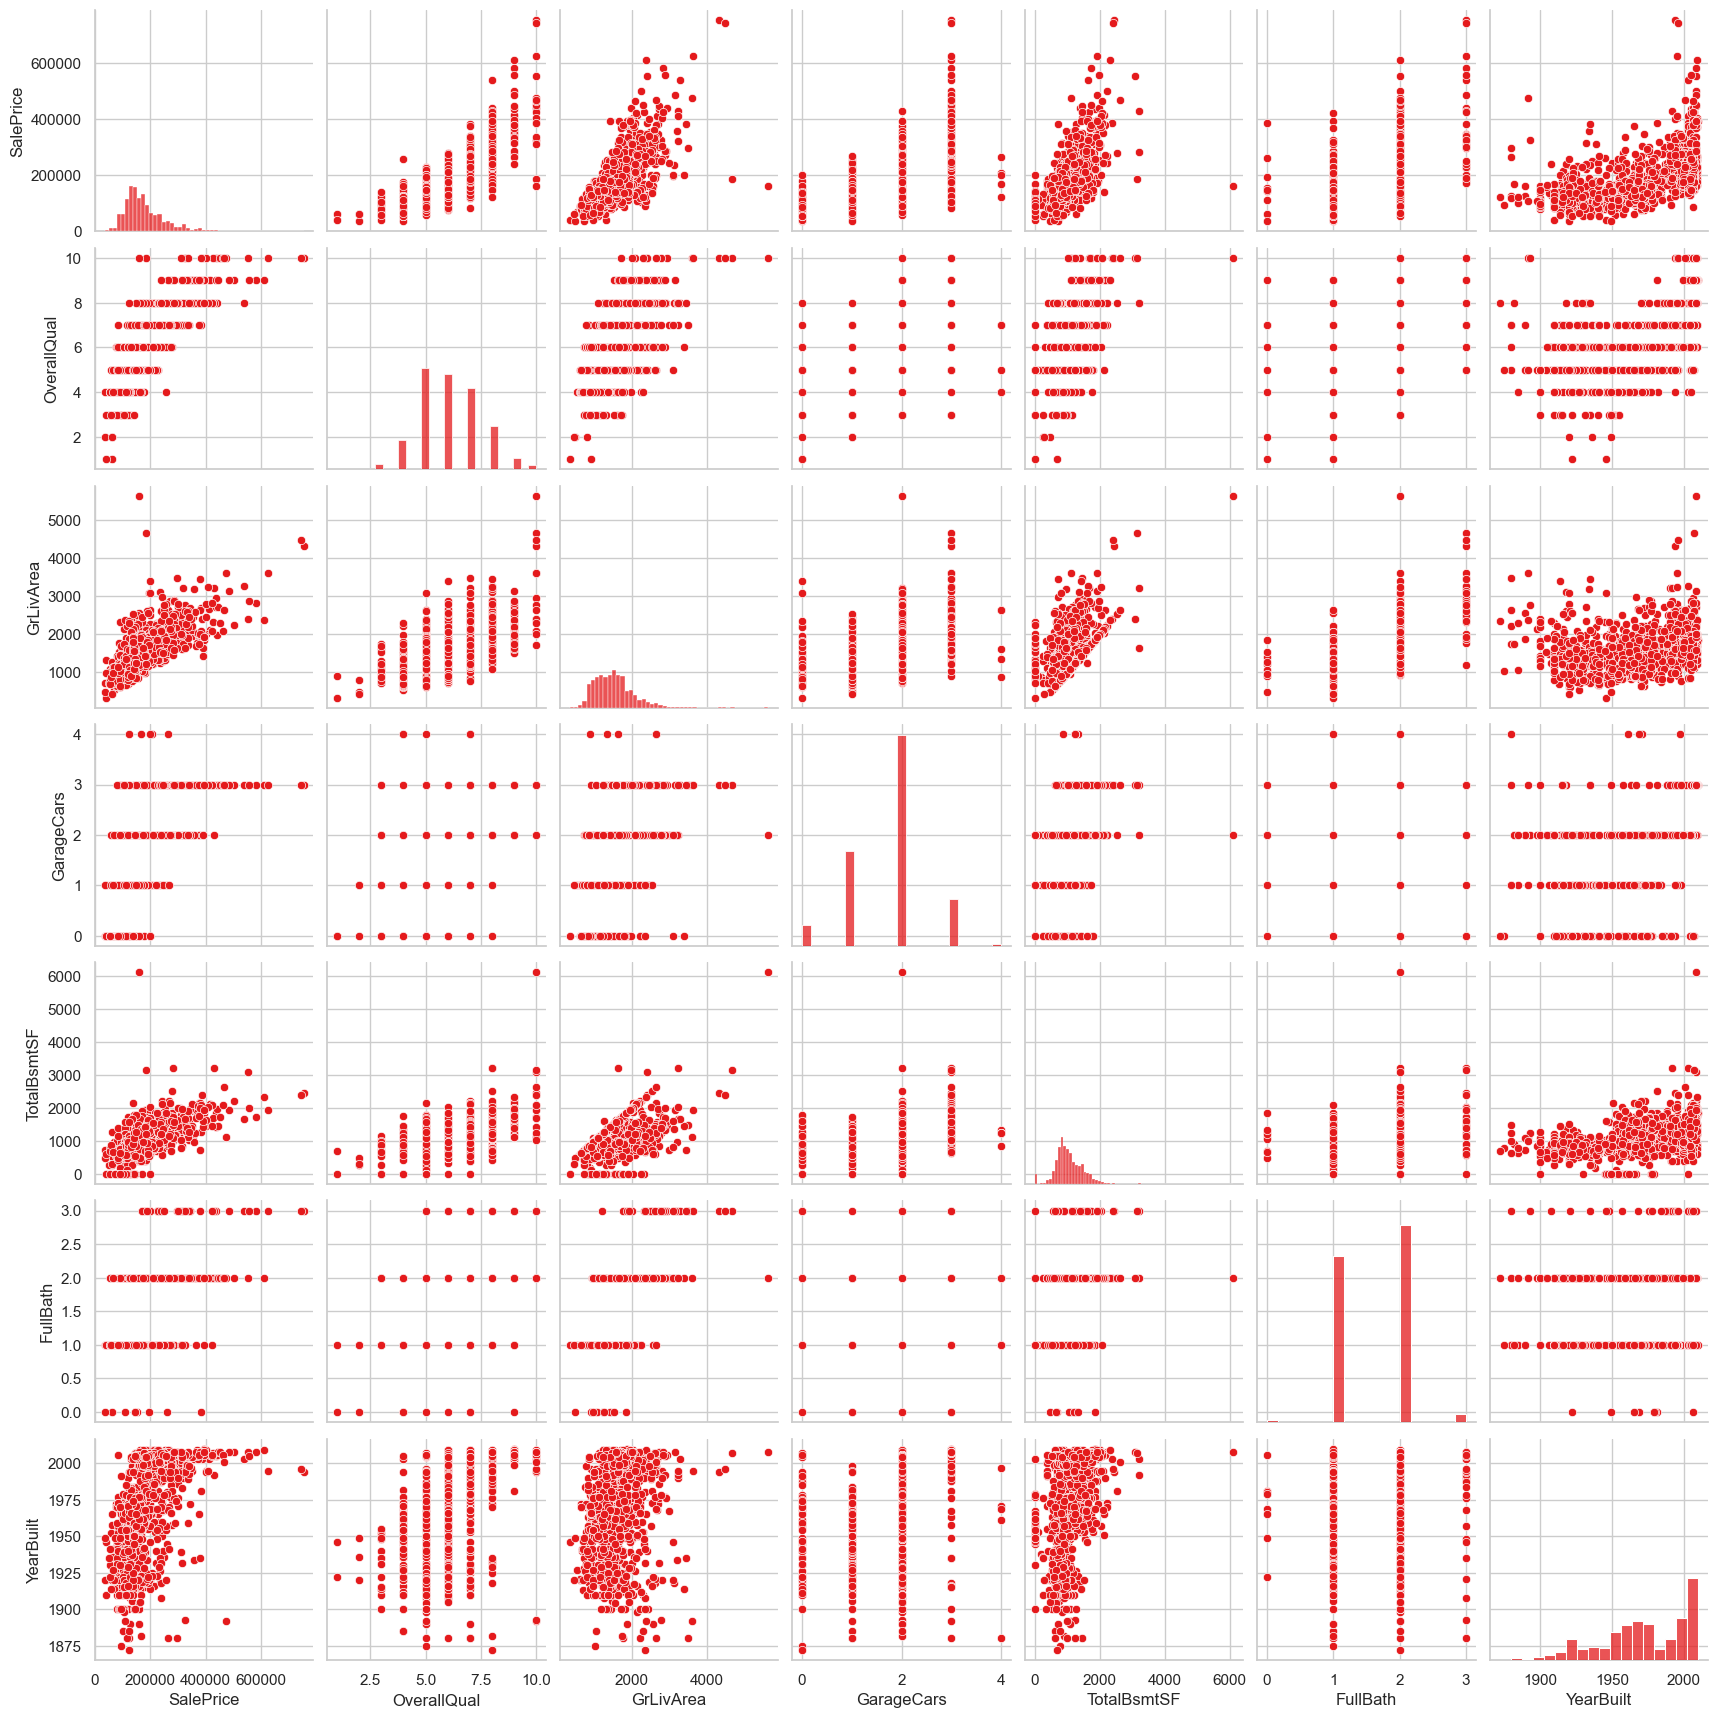

In [14]:
cols = ['SalePrice','OverallQual','GrLivArea','GarageCars','TotalBsmtSF','FullBath','YearBuilt']
sns.pairplot(data=traindata[cols])

发现：

有一些很像边界的线： 比如`TotalBsmtSF` 总是小于`GrLivArea`这是合理的，地上楼层活动面积大于地下室面积

随着建筑年限靠近，价格指数级上升

### 分类特征与目标

```{todo}
如何在这么多特征找到那些关键特征？？

In [15]:
traindata.select_dtypes(include=['object']).columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

`OverallQual` 评分也是分类特征，ordinal

In [16]:
traindata['OverallQual'].value_counts()

OverallQual
5     397
6     374
7     319
8     168
4     116
9      43
3      20
10     18
2       3
1       2
Name: count, dtype: int64

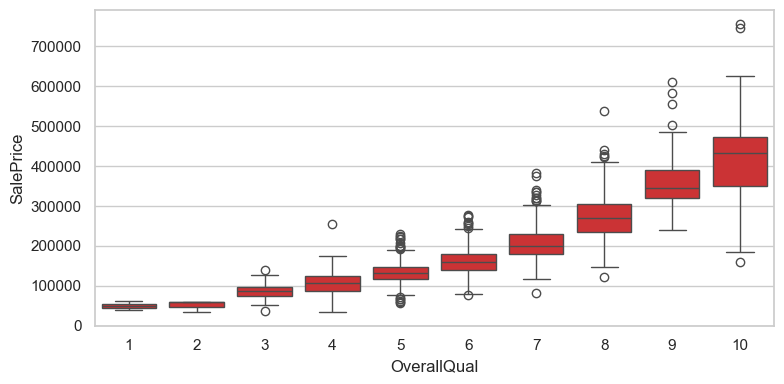

In [17]:
plt.figure(figsize=(8,4))
sns.boxplot(data=traindata, x= 'OverallQual', y='SalePrice')
plt.tight_layout()

In [18]:
traindata['YearBuilt'].dtype

dtype('int64')

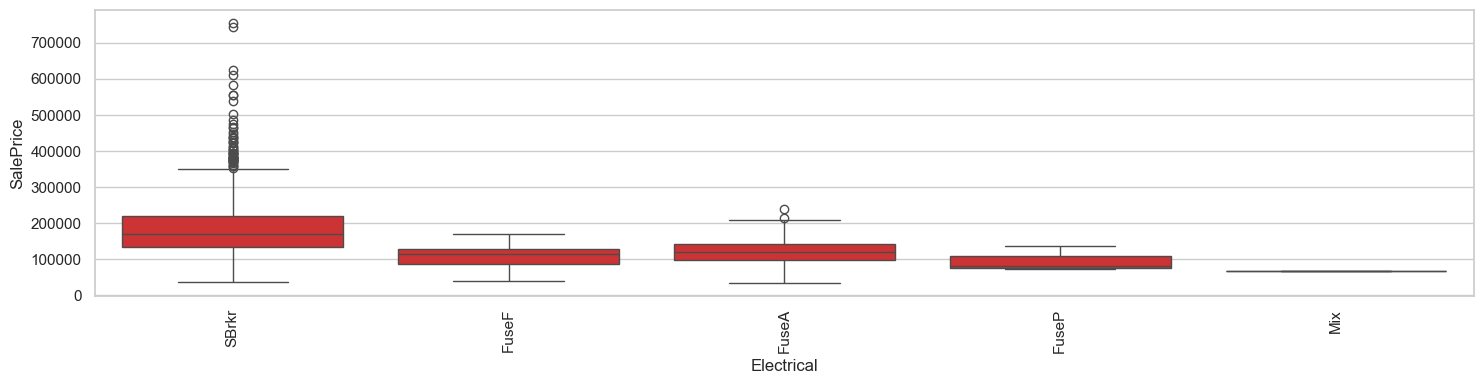

In [19]:
plt.figure(figsize=(15,4))
ax = sns.boxplot(data=traindata, x= 'Electrical', y='SalePrice')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

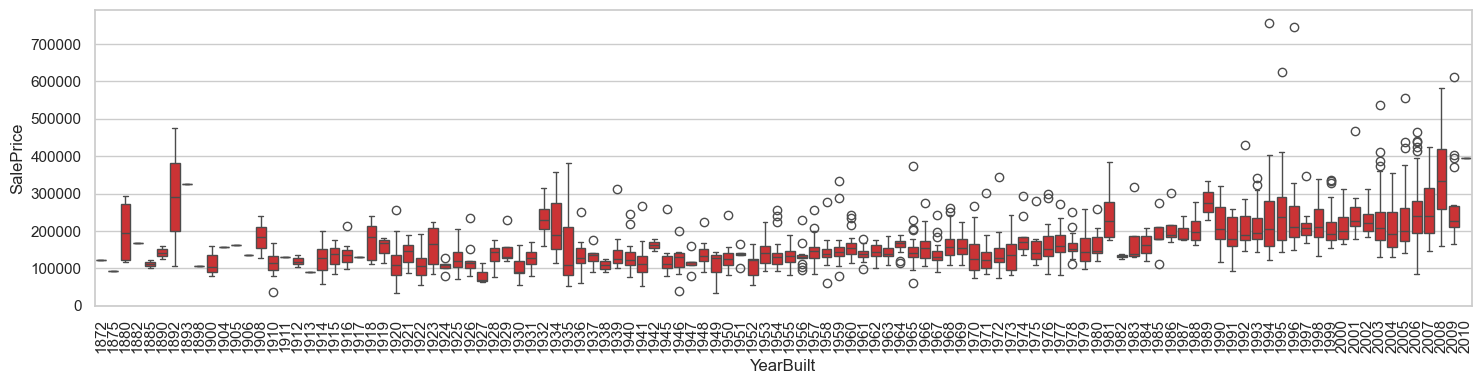

In [20]:
plt.figure(figsize=(15,4))
ax = sns.boxplot(data=traindata, x= 'YearBuilt', y='SalePrice')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 数值特征
- 有数值意义：日期，大小
- 无数值意义：分类

In [ ]:
traindata.select_dtypes(include=['number'])

,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,8450,7,5,2003,2003,706,0,150,856,...,0,61,0,0,0,0,0,2,2008,208500
2,20,9600,6,8,1976,1976,978,0,284,1262,...,298,0,0,0,0,0,0,5,2007,181500
3,60,11250,7,5,2001,2002,486,0,434,920,...,0,42,0,0,0,0,0,9,2008,223500
4,70,9550,7,5,1915,1970,216,0,540,756,...,0,35,272,0,0,0,0,2,2006,140000
5,60,14260,8,5,2000,2000,655,0,490,1145,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,7917,6,5,1999,2000,0,0,953,953,...,0,40,0,0,0,0,0,8,2007,175000
1457,20,13175,6,6,1978,1988,790,163,589,1542,...,349,0,0,0,0,0,0,2,2010,210000
1458,70,9042,7,9,1941,2006,275,0,877,1152,...,0,60,0,0,0,0,2500,5,2010,266500


In [ ]:
numeric_cols = ['LotFrontage','LotArea','MasVnrArea','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','1stFlrSF','2ndFlrSF','LowQualFinSF','GrLivArea','GarageArea',
     'WoodDeckSF','OpenPorchSF','EnclosedPorch','3SsnPorch','ScreenPorch','PoolArea',
     'MiscVal','MoSold' ,'YrSold',
     'BsmtFullBath','BsmtHalfBath','FullBath','HalfBath','BedroomAbvGr','KitchenAbvGr','TotRmsAbvGrd','Fireplaces',
'GarageCars']
print(len(numeric_cols))

30


日期 

In [ ]:
date_cols = ['GarageYrBlt','YearRemodAdd','YearBuilt']

In [ ]:
ax = sns.histplot(data=traindata[date_cols], kde=True)

KeyError: "['GarageYrBlt'] not in index"

### 类别数据

- 无序类别：One-Hot Encoding，Target Encoding， label encoding
- 有序类别： orignal encoding。 有的1-10有正常顺序不需要编码

In [86]:
len(traindata.select_dtypes(include=['object']).columns)

43

In [107]:
categorical_cols = ['MSSubClass','OverallQual','OverallCond',
                    'CentralAir','Alley',
                    'MSZoning','Street','LotShape','LandContour','Utilities','LotConfig','LandSlope',
      'Neighborhood','Condition1','Condition2','BldgType','HouseStyle','RoofStyle','RoofMatl','Exterior1st',
      'Exterior2nd','MasVnrType','Foundation','Heating','Electrical','Functional',
      'GarageType','GarageFinish','PavedDrive','Fence','MiscFeature','SaleType','SaleCondition'
                   ]

In [97]:
len(categorical_cols)

32

这几个虽然dtype是number，但是class

In [98]:
traindata[['MSSubClass','OverallQual','OverallCond']]

,MSSubClass,OverallQual,OverallCond
Id,,,
1,60,7,5
2,20,6,8
3,60,7,5
4,70,7,5
5,60,8,5
...,...,...,...
1456,60,6,5
1457,20,6,6
1458,70,7,9


In [99]:
ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
traindata[ordinal_cols].isnull().sum()

ExterQual          0
ExterCond          0
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
HeatingQC          0
KitchenQual        0
FireplaceQu      690
GarageQual        81
GarageCond        81
PoolQC          1453
dtype: int64

In [ ]:
len(ordinal_cols)

13

In [108]:
set(traindata.columns.to_list()) - set(numeric_cols) -set(date_cols) - set(categorical_cols) - set(ordinal_cols)

{'SalePrice'}

这里cols不是固定的，只是对数据集划分
- 缺失太多会删除列。 
- 特征选择

### missing
- 缺失的程度
- 缺失是否有规律？还是人为异常？

In [21]:
total = traindata.isnull().sum()
percent = traindata.isnull().sum() / traindata.shape[0]
missing_data = pd.concat([total, percent], axis=1, keys=['total', 'percent'])
missing_data.sort_values(by='percent', ascending=False)

,total,percent
PoolQC,1453,0.995205
MiscFeature,1406,0.963014
Alley,1369,0.937671
Fence,1179,0.807534
MasVnrType,872,0.597260
...,...,...
Heating,0,0.000000
HeatingQC,0,0.000000
MSZoning,0,0.000000
1stFlrSF,0,0.000000


In [22]:
missing_data[missing_data['percent'] > 0.15]

,total,percent
LotFrontage,259,0.177397
Alley,1369,0.937671
MasVnrType,872,0.597260
FireplaceQu,690,0.472603
PoolQC,1453,0.995205
Fence,1179,0.807534
MiscFeature,1406,0.963014


缺失比例大于15%，我们考虑删除特征: 

LotFrontage临街的道路面积，Alley道路铺设材料， MasVnrType砖石类型，FireplaceQu壁炉质量，PoolQC泳池质量，Fence围栏质量，MiscFeature杂项。

可以看到这些质量材料相关的缺失，应该不重要，可以删除

In [23]:
missing_data[(missing_data['percent'] <= 0.15) & (missing_data['percent'] >0)]

,total,percent
MasVnrArea,8,0.005479
BsmtQual,37,0.025342
BsmtCond,37,0.025342
BsmtExposure,38,0.026027
BsmtFinType1,37,0.025342
BsmtFinType2,38,0.026027
Electrical,1,0.000685
GarageType,81,0.055479
GarageYrBlt,81,0.055479
GarageFinish,81,0.055479


对于缺失小于15%的，
- *Bsmt* 有相关的 TotalBsmtSF 表示。  删除特征
- *Garage* 有相关的 *GarageCars*。  删除特征
- `Electrical`删除行就可

In [24]:
traindata[traindata['Electrical'].isnull()].index

Index([1380], dtype='int64', name='Id')

In [109]:
traindata = traindata.drop(columns=missing_data[missing_data['total'] > 1].index, axis=1)
traindata = traindata.drop(index=traindata[traindata['Electrical'].isnull()].index,axis=0)

In [115]:
traindata.isnull().sum().sum()

0

### 异常值
- 删除列：缺失15%，可以增加bool保留信息
- 删除行：

**应该聚焦于那些关键的特征！**：
- ['SalePrice','OverallQual','GrLivArea','GarageCars','TotalBsmtSF','FullBath','YearBuilt']


首先，不应该直接使用IQR，因为几乎都是偏态分布的，使用log变换一下

剔除异常值是个困难的问题，面对这么多特征。

[异常值处理办法](https://www.kaggle.com/code/nareshbhat/outlier-the-silent-killer)

这个[链接](https://www.kaggle.com/code/ryanholbrook/feature-engineering-for-house-prices)启发了我看看sklearn的异常值检测


#### 单变量异常

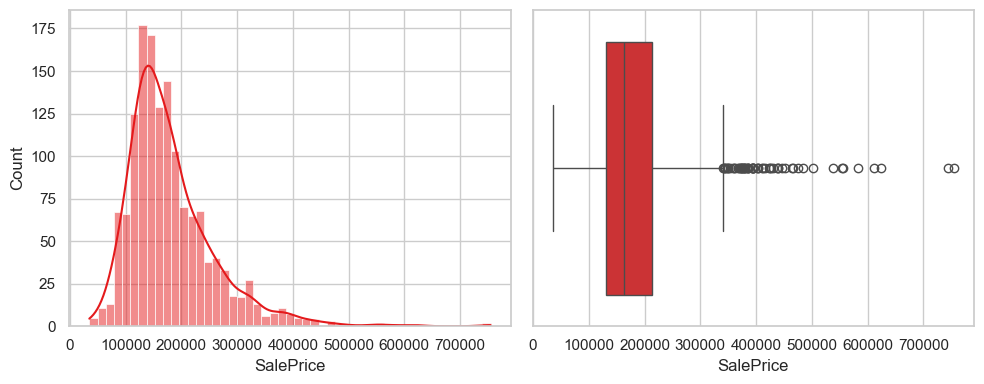

In [136]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,4))
sns.histplot(data=traindata, x='SalePrice', kde=True, ax=ax1)
sns.boxplot(data=traindata, x='SalePrice', ax=ax2)
plt.tight_layout()
plt.show()

#### 多变量异常

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

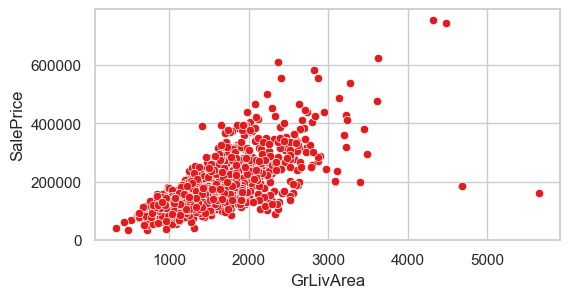

In [30]:
sns.scatterplot(data=traindata, x='GrLivArea', y='SalePrice')

有一些离群点

#### 剔除异常行

In [ ]:
ids = [598, 955, 935, 1299, 250, 314, 336, 707, 379, 1183, 692, 186, 441, 186, 524, 739, 598, 955, 636, 1062, 1191, 496, 198, 1338]

In [ ]:
traindata = traindata.drop(ids, axis=0)

In [ ]:
fig,axes = plt.subplots(len(numeric_cols)//3 + 1, 3, figsize= (15,25))
axes = axes.ravel()
for i,col in enumerate(numeric_cols):
    sns.histplot(traindata[col], ax = axes[i], bins=50,label=f"{col}",kde=True)
fig.tight_layout()

NameError: name 'numeric_cols' is not defined

### log变换
- 方差小一点, 受异常值影响小一点
- glm指数关系

<Axes: xlabel='TotalBsmtSF', ylabel='Count'>

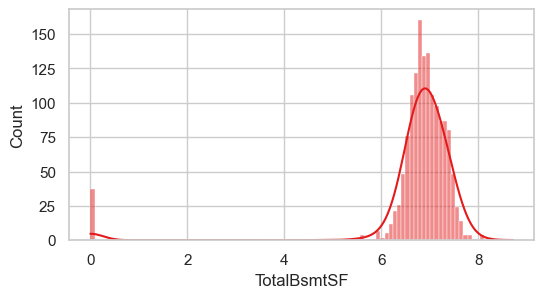

In [48]:
sns.histplot(traindata, x='TotalBsmtSF',kde=True)

- TotalBsmtSF = 0 值太多。 这代表没有地下室。  **我们不能对0做log变换**
- 远端有离群点

为此，我们需要创建一个特征，为了0值。只对非0值做转换

In [ ]:
traindata['HasBsmt'] = 1
traindata['HasBsmt'][traindata[traindata['TotalBsmtSF'] == 0].index] = 0

In [ ]:
traindata.loc[traindata['HasBsmt']==1, 'TotalBsmtSF'] = np.log(traindata.loc[traindata['HasBsmt']==1, 'TotalBsmtSF'])

<Axes: xlabel='TotalBsmtSF', ylabel='Count'>

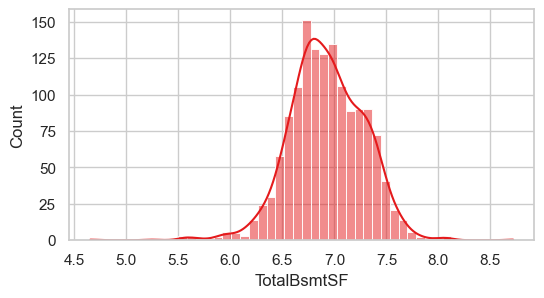

In [47]:
sns.histplot(traindata[traindata['HasBsmt'] == 1], x='TotalBsmtSF',kde=True)

### `Gauss-Markon`假设

#### 误差同方差

这里是不严谨的，应该是n维超线性空间的误差。

但是如果误差方差依赖了某个特征，那么就会波动，不恒定。

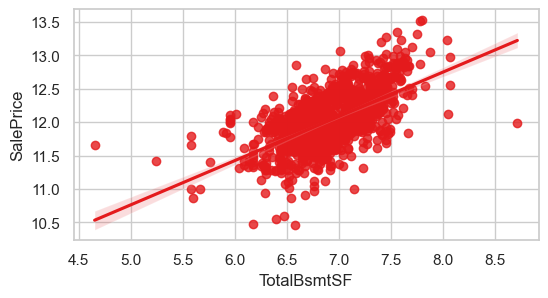

In [ ]:
ax = sns.regplot(traindata[traindata['HasBsmt'] == 1], x='TotalBsmtSF', y='SalePrice')

以`TotalBsmtSF`特征而言，每个x值，y分布沿着回归线一致，即方差不变

### 误差正态假设
为了后续显著性检验

y也是，$\beta$也是

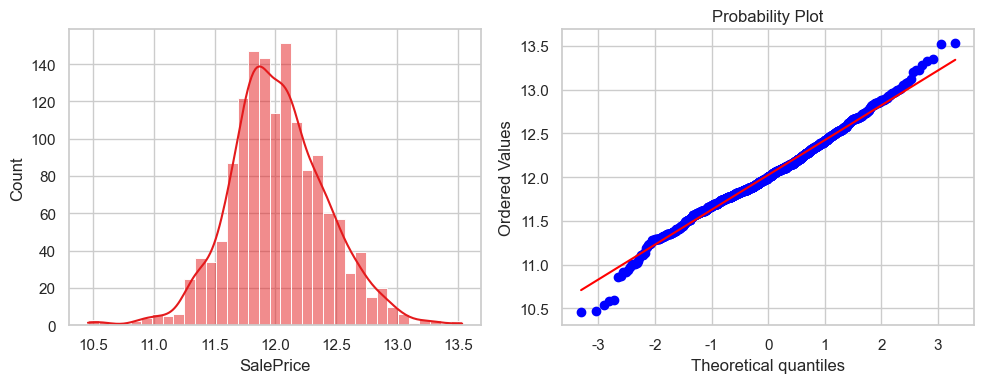

In [43]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
sns.histplot(data=traindata, x='SalePrice',kde=True, ax= ax1)
res = stats.probplot(traindata['SalePrice'], plot=ax2)
plt.tight_layout()
plt.show()

数据向上弯表示右偏，红线为正态分布

通过log变换让他更像正态分布

In [45]:
traindata['SalePrice'] = np.log(traindata['SalePrice'])

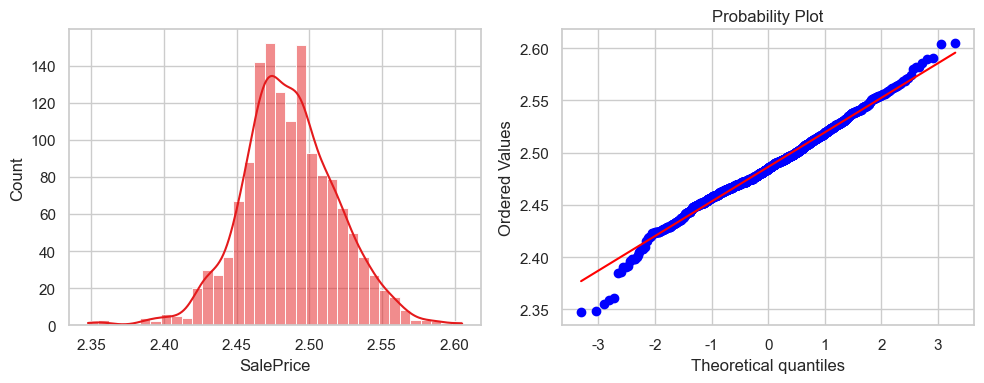

In [46]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
sns.histplot(data=traindata, x='SalePrice',kde=True, ax= ax1)
res = stats.probplot(traindata['SalePrice'], plot=ax2)
plt.tight_layout()
plt.show()

### dummy

In [ ]:
traindata = pd.get_dummies(traindata)

## 确定数据集列，构建XY

In [26]:
traindata_x=traindata[numeric_cols+ordinal_cols+categorical_cols]
traindata_y= traindata.SalePrice
print(traindata_x.shape)

(1439, 75)


## 管道：数据转换

In [29]:
# 函数保持 DataFrame 操作
def fix_garage_yr_blt(df):
    df['GarageYrBlt'] = np.maximum(df['GarageYrBlt'], df['YearBuilt'])
    return df

def add_features(df):
    df['HouseRawYear'] = df['YearRemodAdd'] - df['YearBuilt']
    df['HouseGarageYear'] = df['GarageYrBlt'] - df['YearBuilt']
    df.drop(columns=['YearRemodAdd','YearBuilt','GarageYrBlt'],inplace=True)
    df['HouseRawYear'] = round(df['HouseRawYear']).astype(int)
    df['HouseGarageYear'] = round(df['HouseGarageYear']).astype(int)
    return df.values

In [30]:
date_cols = ['GarageYrBlt','YearBuilt','YearRemodAdd']

In [32]:
date_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('to_dataframe', FunctionTransformer(lambda X: pd.DataFrame(X, columns=date_cols), validate=False)),
    ('fix_garage_yr', FunctionTransformer(fix_garage_yr_blt, validate=False)),
    ('add_features', FunctionTransformer(add_features, validate=False)),
    ('log_transform', FunctionTransformer(np.log1p, validate=False)),  # 取对数
    ('std_scaler', StandardScaler())                                # 标准化
])

In [33]:
date_pipeline.fit_transform(traindata[date_cols])

array([[-0.75318785, -0.49972714],
       [-0.75318785, -0.49972714],
       [-0.33120657, -0.49972714],
       ...,
       [ 1.79743332, -0.49972714],
       [ 1.59074466, -0.49972714],
       [-0.75318785, -0.49972714]])

In [34]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # 填充缺失值
    ('log_transform', FunctionTransformer(np.log1p, validate=False, feature_names_out="one-to-one")),  # 取对数
    ('std_scaler', StandardScaler())                                # 标准化
])

In [35]:
numeric_pipeline.fit_transform(traindata[numeric_cols])

array([[-0.06246848, -0.11160869,  1.21029479, ...,  0.9700246 ,
        -1.01014243,  0.39701995],
       [ 0.6069953 ,  0.14971436, -0.80517363, ..., -0.2188955 ,
         0.75910161,  0.39701995],
       [ 0.08284235,  0.47454859,  1.13802092, ..., -0.2188955 ,
         0.75910161,  0.39701995],
       ...,
       [-0.01331033,  0.02707172, -0.80517363, ...,  1.46846488,
         1.79404302, -0.88068783],
       [ 0.08284235,  0.17452415, -0.80517363, ..., -0.94815264,
        -1.01014243, -0.88068783],
       [ 0.39871115,  0.22037658, -0.80517363, ..., -0.2188955 ,
        -1.01014243, -0.88068783]])

In [36]:
categorical_pipeline  = Pipeline(steps=[
    ('onehot_encoder', OneHotEncoder(handle_unknown='ignore',sparse_output=False))  # 使用 OneHotEncoder
])

In [37]:
categorical_pipeline.fit_transform(traindata[categorical_cols])

array([[0., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.]])

In [38]:
# 对有序类别进行编码
ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='NA')),  # 填充缺失值
    ('ordinal_encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))                 # 使用 OrdinalEncoder
])

In [39]:
ordinal_pipeline.fit_transform(traindata[ordinal_cols])

array([[2., 4., 2., ..., 5., 5., 2.],
       [3., 4., 2., ..., 5., 5., 2.],
       [2., 4., 2., ..., 5., 5., 2.],
       ...,
       [0., 2., 4., ..., 5., 5., 2.],
       [3., 4., 4., ..., 5., 5., 2.],
       [2., 4., 4., ..., 5., 5., 2.]])

In [41]:
preprocessor = ColumnTransformer(
    transformers=[
        #('date',date_pipeline,date_cols),
        ('numeric', numeric_pipeline, numeric_cols),            # 数值型处理
        ('ordianl', ordinal_pipeline, ordinal_cols),            # 有序类别处理
        ('categoric', categorical_pipeline, categorical_cols)     # 无序类别处理
    ]
)


## 训练

In [44]:
model_lasso = make_pipeline(
    preprocessor,
    TransformedTargetRegressor(
        regressor=LassoCV(cv=20, max_iter=5000),
        func=np.log1p,         # 对 y 应用的对数转换
        inverse_func=np.expm1  # 预测时反转
    )
)

In [45]:
model_en = make_pipeline(
    preprocessor,
    TransformedTargetRegressor(
        regressor=ElasticNetCV(cv=20,l1_ratio=0.5),
        func=np.log1p,         # 对 y 应用的对数转换
        inverse_func=np.expm1  # 预测时反转
    )
)

In [46]:
model_ridge = make_pipeline(
    preprocessor,
    TransformedTargetRegressor(
        regressor=RidgeCV(cv=20,),
        func=np.log1p,         # 对 y 应用的对数转换
        inverse_func=np.expm1  # 预测时反转
    )
)

In [47]:
model_poly_linear = make_pipeline(
    preprocessor,
    PolynomialFeatures(degree=2),
    TransformedTargetRegressor(
        regressor=LinearRegression(fit_intercept=False),
        func=np.log1p,         # 对 y 应用的对数转换
        inverse_func=np.expm1  # 预测时反转
    )
)

In [48]:
model_poly_ridge = make_pipeline(
    preprocessor,
    PolynomialFeatures(degree=2),
    TransformedTargetRegressor(
        regressor=RidgeCV(cv=20),
        func=np.log1p,         # 对 y 应用的对数转换
        inverse_func=np.expm1  # 预测时反转
    )
)

In [49]:
model_bayesian_ridge = make_pipeline(
    preprocessor,
    TransformedTargetRegressor(
        regressor=BayesianRidge(),
        func=np.log1p,         # 对 y 应用的对数转换
        inverse_func=np.expm1  # 预测时反转
    )
)

In [122]:
model_dtree = make_pipeline(
    preprocessor,
    TransformedTargetRegressor(
        regressor=DecisionTreeRegressor(
            max_depth=10,
            min_samples_leaf=2,
            min_samples_split=10,
        ),
        func=np.log1p,         # 对 y 应用的对数转换
        inverse_func=np.expm1  # 预测时反转
    )
)

In [123]:
# CV decision tree📌

In [124]:
models = {
    #'LassoCV':model_lasso,
    #'Elastic-Net':model_en,
    #'RidgeCV':model_ridge,
    #'Poly Linear':model_poly_linear,
    #'Poly Ridge':model_poly_ridge,
    #'Bayesian Ridge':model_bayesian_ridge,
    'Decision Tree Regression':model_dtree,
}

In [125]:
X_train, X_test, y_train, y_test = train_test_split(traindata_x,traindata_y,random_state=42,test_size=0.2)

In [126]:
# linear model
import time
for name,m in models.items():
    t1 = time.time()
    m.fit(X_train,y_train)
    print(f"{name} has trained. {(time.time() - t1 ):.2f} s")

Decision Tree Regression has trained. 0.08 s


In [127]:
for name,m in models.items():
    print(f'{name} R^2 : {m.score(X_test, y_test) : .3f}')    

Decision Tree Regression R^2 :  0.757


coef观测

In [110]:
coefs = model[-1].regressor_.coef_
coefs.shape

NameError: name 'model' is not defined

In [759]:
coefs[coefs==0].shape

(150,)

In [760]:
model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log_transform',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('std_scaler',
                                                                   StandardScaler())]),
                                                  ['LotFrontage', 'LotArea',
                                                   'MasVnrArea', 'BsmtFinSF1',
                                                   'BsmtFinSF2', 'BsmtUnfSF',
                                                   'TotalBsm...
                                                   'BldgType', 'HouseStyle',
                                                   'RoofStyle', 'RoofMatl',
                                                   'Exterior1st', 'Exterior2nd',
                                                   'MasVnrType', 'Foundation',
                                                   'Heating', 'Electrical',
                                                   'Functional', 'GarageType',
                                                   'GarageFinish', 'PavedDrive',
                                                   'Fence', 'MiscFeature', ...])])),
                ('transformedtargetregressor',
                 TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                            inverse_func=<ufunc 'expm1'>,
                                            regressor=LassoCV(cv=20,
                                                              max_iter=5000)))])

In [761]:
# 查看训练的稀疏特征
for feature,coef in zip(preprocessor.get_feature_names_out(), coefs):
    if coef==0:
        print(feature)

ordianl__BsmtFinType2
ordianl__PoolQC
categoric__MSSubClass_40
categoric__MSSubClass_45
categoric__MSSubClass_50
categoric__MSSubClass_60
categoric__MSSubClass_70
categoric__MSSubClass_75
categoric__MSSubClass_80
categoric__MSSubClass_85
categoric__MSSubClass_90
categoric__MSSubClass_120
categoric__MSSubClass_160
categoric__MSSubClass_180
categoric__MSSubClass_190
categoric__OverallQual_1
categoric__OverallQual_2
categoric__OverallQual_6
categoric__OverallCond_2
categoric__OverallCond_6
categoric__MSZoning_RH
categoric__MSZoning_RL
categoric__Street_Grvl
categoric__Street_Pave
categoric__LotShape_IR3
categoric__LotShape_Reg
categoric__LandContour_Low
categoric__LandContour_Lvl
categoric__Utilities_AllPub
categoric__Utilities_NoSeWa
categoric__LotConfig_FR3
categoric__LotConfig_Inside
categoric__LandSlope_Gtl
categoric__LandSlope_Mod
categoric__Neighborhood_Blmngtn
categoric__Neighborhood_Blueste
categoric__Neighborhood_BrDale
categoric__Neighborhood_Gilbert
categoric__Neighborhood_NAme

## 预测

In [128]:
testdata = testdata[numeric_cols+ordinal_cols+categorical_cols]

In [129]:
testdata.shape

(1459, 75)

In [130]:
testdata.head()

,LotFrontage,LotArea,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,...,Heating,Electrical,Functional,GarageType,GarageFinish,PavedDrive,Fence,MiscFeature,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
1461,80.0,11622,0.0,468.0,144.0,270.0,882.0,896,0,0,...,GasA,SBrkr,Typ,Attchd,Unf,Y,MnPrv,NaN,WD,Normal
1462,81.0,14267,108.0,923.0,0.0,406.0,1329.0,1329,0,0,...,GasA,SBrkr,Typ,Attchd,Unf,Y,NaN,Gar2,WD,Normal
1463,74.0,13830,0.0,791.0,0.0,137.0,928.0,928,701,0,...,GasA,SBrkr,Typ,Attchd,Fin,Y,MnPrv,NaN,WD,Normal
1464,78.0,9978,20.0,602.0,0.0,324.0,926.0,926,678,0,...,GasA,SBrkr,Typ,Attchd,Fin,Y,NaN,NaN,WD,Normal
1465,43.0,5005,0.0,263.0,0.0,1017.0,1280.0,1280,0,0,...,GasA,SBrkr,Typ,Attchd,RFn,Y,NaN,NaN,WD,Normal


In [131]:
preds = {}

In [132]:
for name,m in models.items():
    testdata_ypred = m.predict(testdata)
    preds[name] = testdata_ypred

In [133]:
preds = pd.DataFrame(preds)
preds.set_index(testdata.index,inplace=True)

## submission

In [134]:
submission_m_name = 'Decision Tree Regression'

In [135]:
submission = pd.DataFrame(
    {
        'Id':preds.index.values,
        'SalePrice':preds[submission_m_name]
    }
)
submission.to_csv('submission.csv', index=False)
submission

,Id,SalePrice
Id,,
1461,1461,104583.674134
1462,1462,153624.223930
1463,1463,177415.601516
1464,1464,171610.424728
1465,1465,200187.514261
...,...,...
2915,2915,84585.694012
2916,2916,84585.694012
2917,2917,139290.011873


In [136]:
submission.describe()

,Id,SalePrice
count,1459.000000,1459.000000
mean,2190.000000,179359.027474
std,421.321334,76924.570756
min,1461.000000,47277.177137
25%,1825.500000,129998.891226
50%,2190.000000,155165.532411
75%,2554.500000,207638.862302
max,2919.000000,498866.646305
